In [2]:
import pandas as pd

gme = pd.read_csv("gme_stock.csv")

print(gme.columns)
print(gme.head())

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object')
         Date  Adj Close   Close    High     Low    Open    Volume Ticker
0  2021-01-04     4.3125  4.3125  4.7750  4.2875  4.7500  40090000    GME
1  2021-01-05     4.3425  4.3425  4.5200  4.3075  4.3375  19846000    GME
2  2021-01-06     4.5900  4.5900  4.7450  4.3325  4.3350  24224800    GME
3  2021-01-07     4.5200  4.5200  4.8625  4.5050  4.6175  24517200    GME
4  2021-01-08     4.4225  4.4225  4.5750  4.2700  4.5450  25928000    GME


In [3]:
gme["Date"] = pd.to_datetime(gme["Date"])

In [4]:
print(gme.dtypes)

Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
Ticker               object
dtype: object


In [5]:
gme["daily_return"] = gme["Close"].pct_change()

In [6]:
print(
    gme[
        ["Date","Close","daily_return"]
    ].head()
)

        Date   Close  daily_return
0 2021-01-04  4.3125           NaN
1 2021-01-05  4.3425      0.006957
2 2021-01-06  4.5900      0.056995
3 2021-01-07  4.5200     -0.015251
4 2021-01-08  4.4225     -0.021571


In [7]:
gme["intraday_return"] = (
    gme["Close"] - gme["Open"]
) / gme["Open"]

In [8]:
print(
    gme[
        ["Date","Open","Close","intraday_return"]
    ].head()
)

        Date    Open   Close  intraday_return
0 2021-01-04  4.7500  4.3125        -0.092105
1 2021-01-05  4.3375  4.3425         0.001153
2 2021-01-06  4.3350  4.5900         0.058824
3 2021-01-07  4.6175  4.5200        -0.021115
4 2021-01-08  4.5450  4.4225        -0.026953


In [9]:
gme["volatility"] = (
    gme["High"] - gme["Low"]
) / gme["Open"]

In [10]:
print(
    gme[
        ["Date","High","Low","volatility"]
    ].head()
)

        Date    High     Low  volatility
0 2021-01-04  4.7750  4.2875    0.102632
1 2021-01-05  4.5200  4.3075    0.048991
2 2021-01-06  4.7450  4.3325    0.095156
3 2021-01-07  4.8625  4.5050    0.077423
4 2021-01-08  4.5750  4.2700    0.067107


In [11]:
gme["avg_volume_20"] = (
    gme["Volume"]
    .rolling(window=20)
    .mean()
)

gme["abnormal_volume"] = (
    gme["Volume"]
    / gme["avg_volume_20"]
)

In [12]:
print(
    gme[
        ["Date","Volume","abnormal_volume"]
    ].tail()
)

         Date     Volume  abnormal_volume
33 2021-02-22   77904000         0.369722
34 2021-02-23   30260800         0.171306
35 2021-02-24  332446800         2.110067
36 2021-02-25  601235200         3.558971
37 2021-02-26  368776800         2.099966


In [13]:
print(gme.isnull().sum())

Date                0
Adj Close           0
Close               0
High                0
Low                 0
Open                0
Volume              0
Ticker              0
daily_return        1
intraday_return     0
volatility          0
avg_volume_20      19
abnormal_volume    19
dtype: int64


In [14]:
gme = gme.dropna()

In [15]:
print(gme.isnull().sum())

Date               0
Adj Close          0
Close              0
High               0
Low                0
Open               0
Volume             0
Ticker             0
daily_return       0
intraday_return    0
volatility         0
avg_volume_20      0
abnormal_volume    0
dtype: int64


In [16]:
print(
    gme[
        [
            "daily_return",
            "intraday_return",
            "volatility",
            "abnormal_volume"
        ]
    ].describe()
)

       daily_return  intraday_return  volatility  abnormal_volume
count     19.000000        19.000000   19.000000        19.000000
mean      -0.013784        -0.055159    0.328092         0.786896
std        0.321012         0.309267    0.262237         0.898656
min       -0.600000        -0.413313    0.084694         0.121324
25%       -0.093193        -0.173185    0.140106         0.225556
50%       -0.022391        -0.076954    0.202182         0.377027
75%        0.026109         0.004235    0.451498         0.956702
max        1.039359         1.051678    1.051678         3.558971


In [17]:
gme.describe()

,Date,Adj Close,Close,High,Low,Open,Volume,daily_return,intraday_return,volatility,avg_volume_20,abnormal_volume
count,19,19.000000,19.000000,19.000000,19.000000,19.000000,1.900000e+01,19.000000,19.000000,19.000000,1.900000e+01,19.000000
mean,2021-02-13 10:06:18.947368448,17.889079,17.889079,23.610921,15.922369,21.193289,1.742080e+08,-0.013784,-0.055159,0.328092,2.549578e+08,0.786896
min,2021-02-01 00:00:00,10.147500,10.147500,10.972500,9.625000,10.320000,3.026080e+07,-0.600000,-0.413313,0.084694,1.575527e+08,0.121324
25%,2021-02-06 12:00:00,11.938750,11.938750,13.086250,11.157500,12.282500,5.880300e+07,-0.093193,-0.173185,0.140106,2.284779e+08,0.225556
50%,2021-02-12 00:00:00,13.100000,13.100000,15.707500,12.055000,13.165000,1.073724e+08,-0.022391,-0.076954,0.202182,2.695271e+08,0.377027
75%,2021-02-20 12:00:00,22.713750,22.713750,26.050000,16.530000,25.400001,2.812208e+08,0.026109,0.004235,0.451498,2.926637e+08,0.956702
max,2021-02-26 00:00:00,56.250000,56.250000,80.500000,53.000000,79.139999,6.012352e+08,1.039359,1.051678,1.051678,3.193832e+08,3.558971
std,NaN,10.801937,10.801937,17.204410,10.026555,16.813706,1.528517e+08,0.321012,0.309267,0.262237,5.239548e+07,0.898656


In [18]:
print(gme.shape)

(19, 13)


In [19]:
import pandas as pd

raw_gme = pd.read_csv("gme_stock.csv")

print("Original rows:", len(raw_gme))
print("Date range:")
print(raw_gme["Date"].min())
print(raw_gme["Date"].max())


Original rows: 38
Date range:
2021-01-04
2021-02-26


In [24]:
print(raw_gme.shape)

(38, 8)


In [22]:
final_df = pd.merge(
    gme_features,
    gme_market,
    on="date"
)

NameError: name 'gme_features' is not defined

In [25]:
%whos

Variable   Type         Data/Info
---------------------------------
gme        DataFrame             Date  Adj Close <...>  \n37         2.099966  
pd         module       <module 'pandas' from 'C:<...>es\\pandas\\__init__.py'>
raw_gme    DataFrame              Date  Adj Close<...> \n37  368776800    GME  


In [26]:
import pandas as pd

gme_features = pd.read_csv("gme_features.csv")

print(gme_features.head())
print(gme_features.shape)

         date  volume  avg_sentiment       isv    avg_score  avg_comments  \
0  2021-01-28     454      -0.125932  0.066379   688.781938     79.918502   
1  2021-01-29    4938      -0.125399  0.087362   320.991900     62.174767   
2  2021-01-30     597      -0.097813  0.073171  4478.422111    632.586265   
3  2021-01-31     449      -0.088861  0.064871  3687.768374    319.937639   
4  2021-02-01     368      -0.097201  0.073035  3653.885870    497.668478   

   sentiment_velocity  
0                 NaN  
1            0.000533  
2            0.027585  
3            0.008952  
4           -0.008339  
(134, 7)


In [28]:
gme_market = pd.read_csv("gme_stock.csv")

In [29]:
print(gme_features.columns)
print(gme_market.columns)

Index(['date', 'volume', 'avg_sentiment', 'isv', 'avg_score', 'avg_comments',
       'sentiment_velocity'],
      dtype='object')
Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume',
       'Ticker'],
      dtype='object')


In [30]:
gme_market.rename(columns={"Date":"date"}, inplace=True)

In [31]:
gme_features["date"] = pd.to_datetime(gme_features["date"])

print("Rows:", len(gme_features))
print("Start:", gme_features["date"].min())
print("End:", gme_features["date"].max())

Rows: 134
Start: 2021-01-28 00:00:00
End: 2021-06-22 00:00:00


In [32]:
gme_features = pd.read_csv("gme_features.csv")

gme_features["date"] = pd.to_datetime(gme_features["date"])

print(gme_features.shape)
print(gme_features["date"].min())
print(gme_features["date"].max())

(134, 7)
2021-01-28 00:00:00
2021-06-22 00:00:00


In [33]:
import yfinance as yf

gme_market = yf.download(
    "GME",
    start="2021-01-28",
    end="2021-06-23"
)

gme_market.reset_index(inplace=True)

print(gme_market.shape)
print(gme_market.head())
print(gme_market.tail())

[*********************100%***********************]  1 of 1 completed

(101, 6)
Price        Date      Close        High      Low       Open     Volume
Ticker                   GME         GME      GME        GME        GME
0      2021-01-28  48.400002  120.750000  28.0625  66.250000  235263200
1      2021-01-29  81.250000  103.495003  62.5000  94.927498  202264400
2      2021-02-01  56.250000   80.500000  53.0000  79.139999  149528800
3      2021-02-02  22.500000   39.500000  18.5550  35.189999  312732400
4      2021-02-03  23.102501   28.350000  21.3125  28.002501  170794000
Price        Date      Close       High        Low       Open    Volume
Ticker                   GME        GME        GME        GME       GME
96     2021-06-16  55.742500  57.182499  52.250000  53.810001  22259200
97     2021-06-17  55.897499  58.415001  55.369999  56.000000  18434400
98     2021-06-18  53.455002  55.872501  53.250000  55.044998  17281200
99     2021-06-21  50.092499  54.599998  49.250000  54.237499  20480800
100    2021-06-22  55.099998  56.470001  52.292500  54.

In [35]:
gme_market.to_csv("gme_market_features.csv", index=False)

In [37]:
print(gme_market.columns)

MultiIndex([(           'Date',    ''),
            (          'Close', 'GME'),
            (           'High', 'GME'),
            (            'Low', 'GME'),
            (           'Open', 'GME'),
            (         'Volume', 'GME'),
            (   'daily_return',    ''),
            ('intraday_return',    ''),
            (     'volatility',    ''),
            (  'avg_volume_20',    '')],
           names=['Price', 'Ticker'])


In [38]:
gme_market.columns = [col[0] for col in gme_market.columns]

print(gme_market.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'daily_return',
       'intraday_return', 'volatility', 'avg_volume_20'],
      dtype='object')


In [39]:
gme_market["daily_return"] = gme_market["Close"].pct_change()

gme_market["intraday_return"] = (
    gme_market["Close"] - gme_market["Open"]
) / gme_market["Open"]

gme_market["volatility"] = (
    gme_market["High"] - gme_market["Low"]
) / gme_market["Open"]

gme_market["avg_volume_20"] = (
    gme_market["Volume"].rolling(20).mean()
)

gme_market["abnormal_volume"] = (
    gme_market["Volume"] / gme_market["avg_volume_20"]
)

In [40]:
print(gme_market[[
    "daily_return",
    "intraday_return",
    "volatility",
    "abnormal_volume"
]].head())

   daily_return  intraday_return  volatility  abnormal_volume
0           NaN        -0.269434    1.399057              NaN
1      0.678719        -0.144084    0.431856              NaN
2     -0.307692        -0.289234    0.347485              NaN
3     -0.600000        -0.360614    0.595198              NaN
4      0.026778        -0.174984    0.251317              NaN


In [41]:
gme_market.dropna(inplace=True)

print(gme_market.shape)

(82, 11)


In [42]:
print(gme_market.columns)
print(gme_market.shape)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'daily_return',
       'intraday_return', 'volatility', 'avg_volume_20', 'abnormal_volume'],
      dtype='object')
(82, 11)


In [43]:
gme_market.to_csv(
    "gme_market_features.csv",
    index=False
)

print("GME market features saved")

GME market features saved


In [44]:
gme_market.rename(
    columns={"Date":"date"},
    inplace=True
)

In [45]:
gme_market["date"] = pd.to_datetime(gme_market["date"])
gme_features["date"] = pd.to_datetime(gme_features["date"])

In [46]:
final_gme = pd.merge(
    gme_features,
    gme_market[
        [
            "date",
            "daily_return",
            "intraday_return",
            "volatility",
            "abnormal_volume"
        ]
    ],
    on="date",
    how="inner"
)

In [47]:
print(final_gme.shape)
print(final_gme.columns)

(73, 11)
Index(['date', 'volume', 'avg_sentiment', 'isv', 'avg_score', 'avg_comments',
       'sentiment_velocity', 'daily_return', 'intraday_return', 'volatility',
       'abnormal_volume'],
      dtype='object')


In [48]:
final_gme.to_csv(
    "final_gme_dataset.csv",
    index=False
)

print("Final GME dataset saved")

Final GME dataset saved


In [49]:
import pandas as pd
import yfinance as yf

# ==========================================
# FUNCTION TO PROCESS A STOCK
# ==========================================

def process_stock(ticker, feature_file):

    # -------------------------------
    # Load sentiment features
    # -------------------------------
    features = pd.read_csv(feature_file)

    features["date"] = pd.to_datetime(features["date"])

    start_date = features["date"].min()
    end_date = features["date"].max()

    print(f"\nProcessing {ticker}")
    print("Sentiment Period:")
    print(start_date, "to", end_date)

    # -------------------------------
    # Download market data
    # -------------------------------
    market = yf.download(
        ticker,
        start=start_date,
        end=end_date + pd.Timedelta(days=1),
        progress=False
    )

    market.reset_index(inplace=True)

    # -------------------------------
    # Fix MultiIndex columns
    # -------------------------------
    market.columns = [
        col[0] if isinstance(col, tuple) else col
        for col in market.columns
    ]

    # -------------------------------
    # Market Features
    # -------------------------------
    market["daily_return"] = market["Close"].pct_change()

    market["intraday_return"] = (
        market["Close"] - market["Open"]
    ) / market["Open"]

    market["volatility"] = (
        market["High"] - market["Low"]
    ) / market["Open"]

    market["avg_volume_20"] = (
        market["Volume"]
        .rolling(window=20)
        .mean()
    )

    market["abnormal_volume"] = (
        market["Volume"]
        / market["avg_volume_20"]
    )

    # Remove NaNs
    market.dropna(inplace=True)

    # -------------------------------
    # Save market features
    # -------------------------------
    market.rename(
        columns={"Date": "date"},
        inplace=True
    )

    market_file = f"{ticker.lower()}_market_features.csv"

    market.to_csv(
        market_file,
        index=False
    )

    print(f"Saved: {market_file}")

    # -------------------------------
    # Merge with sentiment features
    # -------------------------------
    final_dataset = pd.merge(
        features,
        market[
            [
                "date",
                "daily_return",
                "intraday_return",
                "volatility",
                "abnormal_volume"
            ]
        ],
        on="date",
        how="inner"
    )

    final_file = f"final_{ticker.lower()}_dataset.csv"

    final_dataset.to_csv(
        final_file,
        index=False
    )

    print(f"Saved: {final_file}")
    print("Shape:", final_dataset.shape)

    return final_dataset


# ==========================================
# AMC
# ==========================================

final_amc = process_stock(
    ticker="AMC",
    feature_file="amc_features.csv"
)

# ==========================================
# TSLA
# ==========================================

final_tsla = process_stock(
    ticker="TSLA",
    feature_file="tsla_features.csv"
)

# ==========================================
# CHECK RESULTS
# ==========================================

print("\nAMC")
print(final_amc.shape)

print("\nTSLA")
print(final_tsla.shape)


Processing AMC
Sentiment Period:
2021-01-28 00:00:00 to 2021-06-22 00:00:00
Saved: amc_market_features.csv
Saved: final_amc_dataset.csv
Shape: (72, 11)

Processing TSLA
Sentiment Period:
2020-09-29 00:00:00 to 2021-06-22 00:00:00
Saved: tsla_market_features.csv
Saved: final_tsla_dataset.csv
Shape: (90, 11)

AMC
(72, 11)

TSLA
(90, 11)


In [1]:
import pandas as pd

gme = pd.read_csv("final_gme_dataset.csv")
amc = pd.read_csv("final_amc_dataset.csv")
tsla = pd.read_csv("final_tsla_dataset.csv")

In [2]:
print(gme.columns)

Index(['date', 'volume', 'avg_sentiment', 'isv', 'avg_score', 'avg_comments',
       'sentiment_velocity', 'daily_return', 'intraday_return', 'volatility',
       'abnormal_volume'],
      dtype='object')


In [3]:
features = [
    'volume',
    'avg_sentiment',
    'isv',
    'avg_score',
    'avg_comments',
    'sentiment_velocity',
    'daily_return',
    'intraday_return',
    'volatility',
    'abnormal_volume'
]

In [4]:
pearson_gme = gme[features].corr(method='pearson')

print(pearson_gme)

                      volume  avg_sentiment       isv  avg_score  \
volume              1.000000      -0.147935 -0.099387   0.051690   
avg_sentiment      -0.147935       1.000000 -0.110283  -0.348441   
isv                -0.099387      -0.110283  1.000000   0.092033   
avg_score           0.051690      -0.348441  0.092033   1.000000   
avg_comments       -0.005628      -0.207046 -0.033689   0.525396   
sentiment_velocity -0.000693       0.640722 -0.259594  -0.203860   
daily_return        0.081664      -0.043758 -0.078099  -0.020695   
intraday_return    -0.019261       0.004391  0.053946  -0.028226   
volatility          0.605519      -0.228919 -0.115129   0.197721   
abnormal_volume     0.164683      -0.200738 -0.085881   0.105147   

                    avg_comments  sentiment_velocity  daily_return  \
volume                 -0.005628           -0.000693      0.081664   
avg_sentiment          -0.207046            0.640722     -0.043758   
isv                    -0.033689         

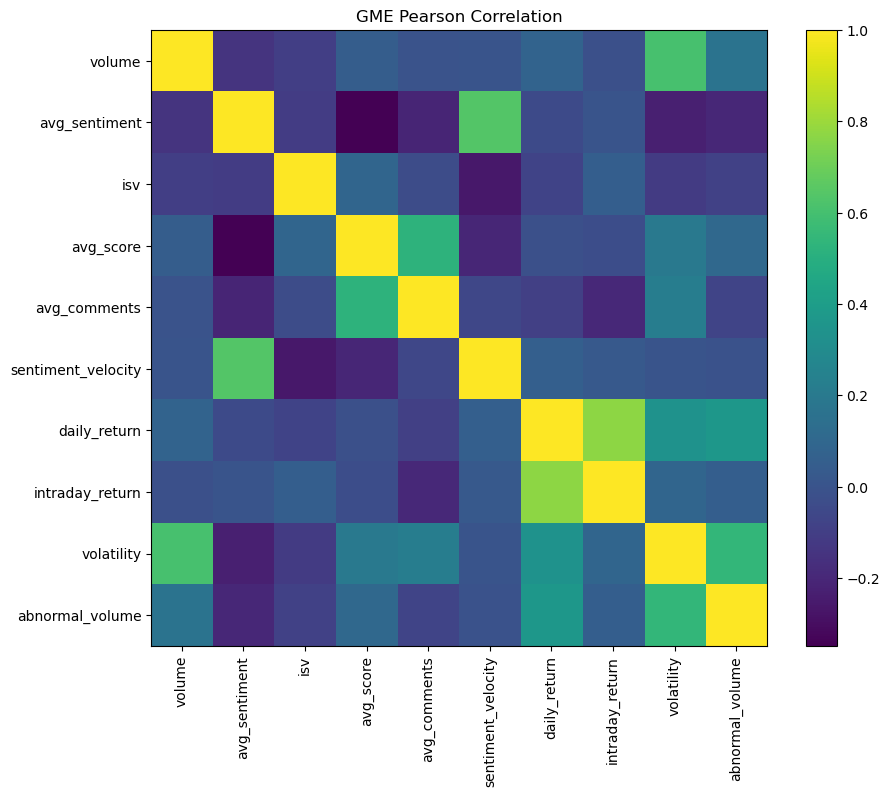

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(pearson_gme)
plt.colorbar()
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("GME Pearson Correlation")
plt.show()

In [6]:
pearson_amc = amc[features].corr(method='pearson')

print("AMC Pearson Correlation")
print(pearson_amc)

AMC Pearson Correlation
                      volume  avg_sentiment       isv  avg_score  \
volume              1.000000       0.067178  0.121424   0.021889   
avg_sentiment       0.067178       1.000000  0.009161  -0.142484   
isv                 0.121424       0.009161  1.000000   0.308298   
avg_score           0.021889      -0.142484  0.308298   1.000000   
avg_comments        0.080892      -0.052823  0.316191   0.440777   
sentiment_velocity  0.006329       0.710610 -0.103793  -0.279298   
daily_return       -0.067704      -0.164522 -0.086223   0.035083   
intraday_return    -0.158258      -0.152637 -0.052551   0.076201   
volatility          0.335821      -0.125416  0.125820   0.116490   
abnormal_volume     0.042530      -0.015252  0.046675   0.210459   

                    avg_comments  sentiment_velocity  daily_return  \
volume                  0.080892            0.006329     -0.067704   
avg_sentiment          -0.052823            0.710610     -0.164522   
isv              

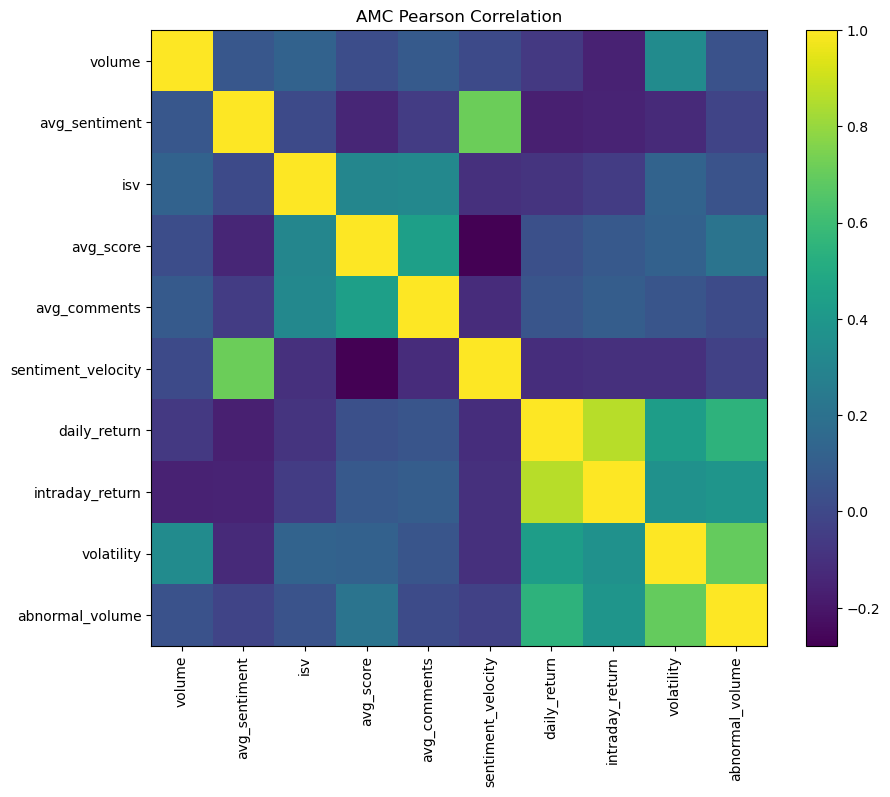

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(pearson_amc)
plt.colorbar()

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.title("AMC Pearson Correlation")
plt.show()

In [8]:
pearson_tsla = tsla[features].corr(method='pearson')

print("TSLA Pearson Correlation")
print(pearson_tsla)

TSLA Pearson Correlation
                      volume  avg_sentiment       isv  avg_score  \
volume              1.000000      -0.162634  0.135029   0.002068   
avg_sentiment      -0.162634       1.000000 -0.026812  -0.093681   
isv                 0.135029      -0.026812  1.000000  -0.094845   
avg_score           0.002068      -0.093681 -0.094845   1.000000   
avg_comments       -0.099037      -0.162486 -0.099903   0.577476   
sentiment_velocity -0.063622       0.530017 -0.004611  -0.031120   
daily_return       -0.190445       0.046375 -0.063601  -0.024391   
intraday_return    -0.241267      -0.077011 -0.025422  -0.049417   
volatility          0.295422      -0.072192  0.059869  -0.048541   
abnormal_volume     0.213500      -0.054977  0.238702  -0.028576   

                    avg_comments  sentiment_velocity  daily_return  \
volume                 -0.099037           -0.063622     -0.190445   
avg_sentiment          -0.162486            0.530017      0.046375   
isv             

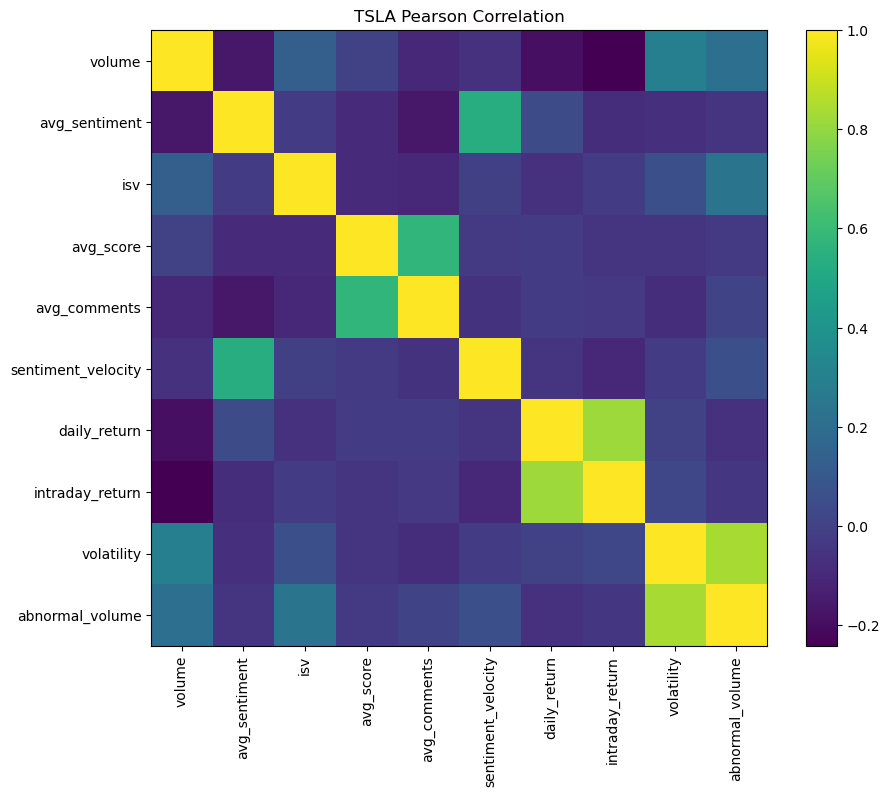

In [9]:
plt.figure(figsize=(10,8))
plt.imshow(pearson_tsla)
plt.colorbar()

plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)

plt.title("TSLA Pearson Correlation")
plt.show()

In [10]:
spearman_amc = amc[features].corr(method='spearman')

print("AMC Spearman Correlation")
print(spearman_amc)

AMC Spearman Correlation
                      volume  avg_sentiment       isv  avg_score  \
volume              1.000000       0.014650  0.542895   0.135479   
avg_sentiment       0.014650       1.000000 -0.064903  -0.188758   
isv                 0.542895      -0.064903  1.000000   0.121312   
avg_score           0.135479      -0.188758  0.121312   1.000000   
avg_comments       -0.074718      -0.092370  0.153282   0.567726   
sentiment_velocity -0.012569       0.642935 -0.079351  -0.046595   
daily_return       -0.083091      -0.157920 -0.126315  -0.133481   
intraday_return    -0.157922      -0.166474 -0.155437  -0.166827   
volatility          0.478105      -0.152872  0.278952  -0.055631   
abnormal_volume     0.062472      -0.137919  0.116694  -0.017236   

                    avg_comments  sentiment_velocity  daily_return  \
volume                 -0.074718           -0.012569     -0.083091   
avg_sentiment          -0.092370            0.642935     -0.157920   
isv             

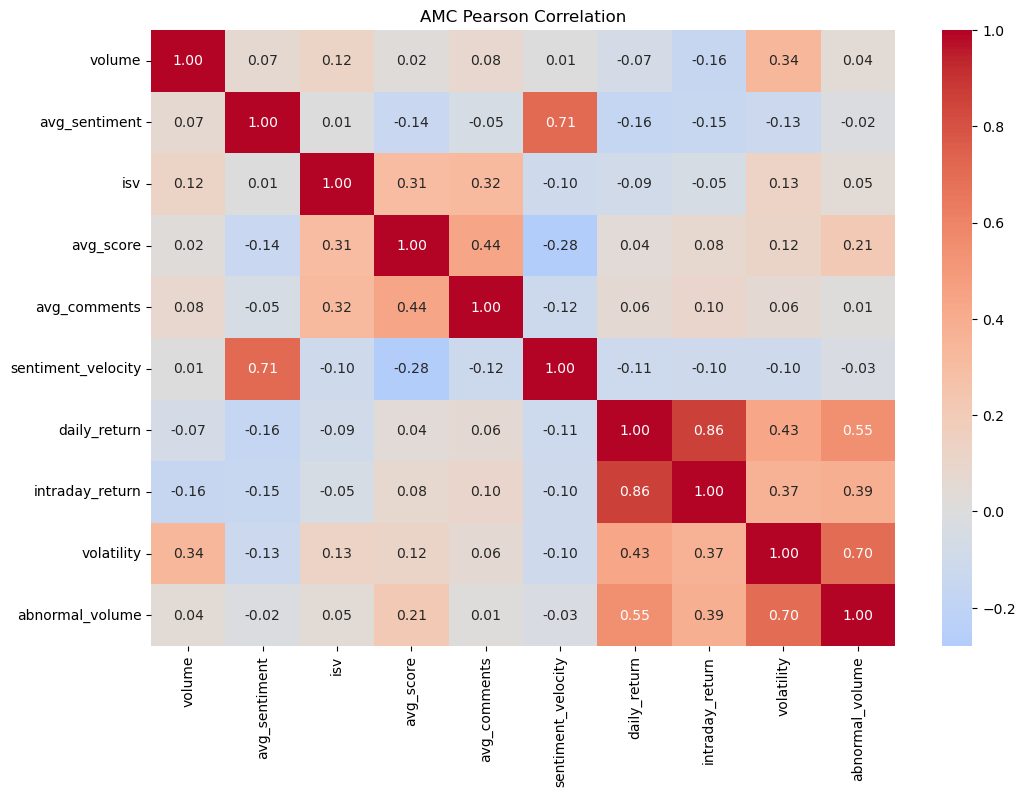

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    pearson_amc,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("AMC Pearson Correlation")
plt.show()

In [12]:
import statsmodels.api as sm

X = gme[
    [
        'isv',
        'volume',
        'sentiment_velocity',
        'avg_comments'
    ]
]

y = gme['volatility']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     12.29
Date:                Thu, 06 Aug 2026   Prob (F-statistic):           1.42e-07
Time:                        21:33:56   Log-Likelihood:                 68.781
No. Observations:                  73   AIC:                            -127.6
Df Residuals:                      68   BIC:                            -116.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0791      0

In [13]:
import statsmodels.api as sm

X = amc[
    [
        'isv',
        'volume',
        'sentiment_velocity',
        'avg_comments'
    ]
]

y = amc['volatility']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     2.480
Date:                Thu, 06 Aug 2026   Prob (F-statistic):             0.0521
Time:                        21:34:03   Log-Likelihood:                 74.128
No. Observations:                  72   AIC:                            -138.3
Df Residuals:                      67   BIC:                            -126.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0909      0

In [14]:
import statsmodels.api as sm

X = tsla[
    [
        'isv',
        'volume',
        'sentiment_velocity',
        'avg_comments'
    ]
]

y = tsla['volatility']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             volatility   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     2.103
Date:                Thu, 06 Aug 2026   Prob (F-statistic):             0.0875
Time:                        21:34:09   Log-Likelihood:                 204.33
No. Observations:                  90   AIC:                            -398.7
Df Residuals:                      85   BIC:                            -386.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0421      0

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = gme[
    [
        'isv',
        'volume',
        'sentiment_velocity',
        'avg_comments'
    ]
]

vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

             Variable       VIF
0                 isv  1.691865
1              volume  1.335317
2  sentiment_velocity  1.033300
3        avg_comments  1.557412


In [16]:
X = amc[
    [
        'isv',
        'volume',
        'sentiment_velocity',
        'avg_comments'
    ]
]

vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

             Variable       VIF
0                 isv  1.883876
1              volume  1.526058
2  sentiment_velocity  1.009210
3        avg_comments  1.879254


In [17]:
X = tsla[
    [
        'isv',
        'volume',
        'sentiment_velocity',
        'avg_comments'
    ]
]

vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

             Variable       VIF
0                 isv  1.679796
1              volume  1.642804
2  sentiment_velocity  1.003482
3        avg_comments  1.398890


In [19]:
grangercausalitytests(
    gme[['volatility','volume']],
    maxlag=3,
    verbose=True
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=5.3411  , p=0.0238  , df_denom=69, df_num=1
ssr based chi2 test:   chi2=5.5734  , p=0.0182  , df=1
likelihood ratio test: chi2=5.3682  , p=0.0205  , df=1
parameter F test:         F=5.3411  , p=0.0238  , df_denom=69, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.1669  , p=0.1226  , df_denom=66, df_num=2
ssr based chi2 test:   chi2=4.6622  , p=0.0972  , df=2
likelihood ratio test: chi2=4.5155  , p=0.1046  , df=2
parameter F test:         F=2.1669  , p=0.1226  , df_denom=66, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.0523  , p=0.0349  , df_denom=63, df_num=3
ssr based chi2 test:   chi2=10.1743 , p=0.0171  , df=3
likelihood ratio test: chi2=9.4995  , p=0.0233  , df=3
parameter F test:         F=3.0523  , p=0.0349  , df_denom=63, df_num=3


C:\Users\srima\anaconda_projects\AQI\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(5.3411360549395),
    np.float64(0.02382143426953442),
    np.float64(69.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(5.573359361675999),
    np.float64(0.018235742147333114),
    np.int64(1)),
   'lrtest': (np.float64(5.368171826506682),
    np.float64(0.020507460567771908),
    np.int64(1)),
   'params_ftest': (np.float64(5.341136054939415),
    np.float64(0.023821434269535428),
    np.float64(69.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.1669264007230455),
    np.float64(0.12260957949295304),
    np.float64(66.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(4.662174983373824),
    np.float64(0.09718999628538327),
    np.int64(2)),
   'lrtest': (np.float64(4.51549268753331),
    np.float64(0.10458592007067145),
    np.int64(2)),
   'params_ftest': (np.float64(2.1669264007229483),
    np.float64(0.12260957949296357),
    np.float64(66.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
        

In [20]:
grangercausalitytests(
    gme[['abnormal_volume','volume']],
    maxlag=3
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.1950  , p=0.2781  , df_denom=69, df_num=1
ssr based chi2 test:   chi2=1.2470  , p=0.2641  , df=1
likelihood ratio test: chi2=1.2363  , p=0.2662  , df=1
parameter F test:         F=1.1950  , p=0.2781  , df_denom=69, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4793  , p=0.6213  , df_denom=66, df_num=2
ssr based chi2 test:   chi2=1.0313  , p=0.5971  , df=2
likelihood ratio test: chi2=1.0239  , p=0.5993  , df=2
parameter F test:         F=0.4793  , p=0.6213  , df_denom=66, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2349  , p=0.8717  , df_denom=63, df_num=3
ssr based chi2 test:   chi2=0.7829  , p=0.8535  , df=3
likelihood ratio test: chi2=0.7786  , p=0.8546  , df=3
parameter F test:         F=0.2349  , p=0.8717  , df_denom=63, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(1.1950309643797754),
    np.float64(0.2781190129245627),
    np.float64(69.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.2469888323962874),
    np.float64(0.2641283742095669),
    np.int64(1)),
   'lrtest': (np.float64(1.2363134361125532),
    np.float64(0.266182729277573),
    np.int64(1)),
   'params_ftest': (np.float64(1.195030964379807),
    np.float64(0.2781190129245536),
    np.float64(69.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.4793322947160752),
    np.float64(0.6213352807861745),
    np.float64(66.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(1.0312906946921618),
    np.float64(0.5971151235899497),
    np.int64(2)),
   'lrtest': (np.float64(1.023872578936178),
    np.float64(0.5993339705152603),
    np.int64(2)),
   'params_ftest': (np.float64(0.479332294716047),
    np.float64(0.6213352807861932),
    np.float64(66.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0.,

In [21]:
grangercausalitytests(
    gme[['volatility','isv']],
    maxlag=3
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1164  , p=0.7340  , df_denom=69, df_num=1
ssr based chi2 test:   chi2=0.1215  , p=0.7274  , df=1
likelihood ratio test: chi2=0.1214  , p=0.7276  , df=1
parameter F test:         F=0.1164  , p=0.7340  , df_denom=69, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.9633  , p=0.1485  , df_denom=66, df_num=2
ssr based chi2 test:   chi2=4.2242  , p=0.1210  , df=2
likelihood ratio test: chi2=4.1033  , p=0.1285  , df=2
parameter F test:         F=1.9633  , p=0.1485  , df_denom=66, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3794  , p=0.2572  , df_denom=63, df_num=3
ssr based chi2 test:   chi2=4.5980  , p=0.2037  , df=3
likelihood ratio test: chi2=4.4533  , p=0.2165  , df=3
parameter F test:         F=1.3794  , p=0.2572  , df_denom=63, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.1164134209947594),
    np.float64(0.7339942741297573),
    np.float64(69.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.12147487408148809),
    np.float64(0.7274403423050302),
    np.int64(1)),
   'lrtest': (np.float64(0.12137251596499254),
    np.float64(0.7275506266376386),
    np.int64(1)),
   'params_ftest': (np.float64(0.11641342099477801),
    np.float64(0.7339942741297404),
    np.float64(69.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(1.9633394488128917),
    np.float64(0.14850261332375694),
    np.float64(66.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(4.224154571688342),
    np.float64(0.12098638191887684),
    np.int64(2)),
   'lrtest': (np.float64(4.103267979259613),
    np.float64(0.1285247238528649),
    np.int64(2)),
   'params_ftest': (np.float64(1.9633394488128983),
    np.float64(0.1485026133237558),
    np.float64(66.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
       

In [22]:
grangercausalitytests(
    gme[['daily_return','avg_sentiment']],
    maxlag=3
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.7707  , p=0.3831  , df_denom=69, df_num=1
ssr based chi2 test:   chi2=0.8042  , p=0.3698  , df=1
likelihood ratio test: chi2=0.7997  , p=0.3712  , df=1
parameter F test:         F=0.7707  , p=0.3831  , df_denom=69, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3878  , p=0.6801  , df_denom=66, df_num=2
ssr based chi2 test:   chi2=0.8343  , p=0.6589  , df=2
likelihood ratio test: chi2=0.8295  , p=0.6605  , df=2
parameter F test:         F=0.3878  , p=0.6801  , df_denom=66, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2437  , p=0.8655  , df_denom=63, df_num=3
ssr based chi2 test:   chi2=0.8123  , p=0.8465  , df=3
likelihood ratio test: chi2=0.8077  , p=0.8476  , df=3
parameter F test:         F=0.2437  , p=0.8655  , df_denom=63, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.7706715689742014),
    np.float64(0.38305600080134294),
    np.float64(69.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.8041790284948189),
    np.float64(0.36984683848029976),
    np.int64(1)),
   'lrtest': (np.float64(0.7997211919145002),
    np.float64(0.371176741626428),
    np.int64(1)),
   'params_ftest': (np.float64(0.7706715689741858),
    np.float64(0.38305600080135016),
    np.float64(69.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.3877930812825506),
    np.float64(0.680088570563308),
    np.float64(66.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.8343426900321542),
    np.float64(0.6589080096675806),
    np.int64(2)),
   'lrtest': (np.float64(0.829478452456101),
    np.float64(0.6605125025852512),
    np.int64(2)),
   'params_ftest': (np.float64(0.38779308128254786),
    np.float64(0.6800885705633105),
    np.float64(66.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
         

In [23]:
grangercausalitytests(
    amc[['volatility','volume']],
    maxlag=3
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0797  , p=0.7785  , df_denom=68, df_num=1
ssr based chi2 test:   chi2=0.0832  , p=0.7730  , df=1
likelihood ratio test: chi2=0.0832  , p=0.7730  , df=1
parameter F test:         F=0.0797  , p=0.7785  , df_denom=68, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2837  , p=0.7539  , df_denom=65, df_num=2
ssr based chi2 test:   chi2=0.6111  , p=0.7367  , df=2
likelihood ratio test: chi2=0.6084  , p=0.7377  , df=2
parameter F test:         F=0.2837  , p=0.7539  , df_denom=65, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0822  , p=0.9695  , df_denom=62, df_num=3
ssr based chi2 test:   chi2=0.2743  , p=0.9648  , df=3
likelihood ratio test: chi2=0.2738  , p=0.9649  , df=3
parameter F test:         F=0.0822  , p=0.9695  , df_denom=62, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.07970976963376758),
    np.float64(0.7785486636610971),
    np.float64(68.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.08322637711761027),
    np.float64(0.7729718207392355),
    np.int64(1)),
   'lrtest': (np.float64(0.08317763612006956),
    np.float64(0.7730364859202485),
    np.int64(1)),
   'params_ftest': (np.float64(0.0797097696337659),
    np.float64(0.7785486636610971),
    np.float64(68.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.28370577097443417),
    np.float64(0.7539157619785484),
    np.float64(65.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.6110585836372429),
    np.float64(0.7367333242545269),
    np.int64(2)),
   'lrtest': (np.float64(0.6084069141863324),
    np.float64(0.7377107586943037),
    np.int64(2)),
   'params_ftest': (np.float64(0.28370577097443306),
    np.float64(0.7539157619785484),
    np.float64(65.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
     

In [24]:
grangercausalitytests(
    tsla[['volatility','volume']],
    maxlag=3
)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3734  , p=0.5428  , df_denom=86, df_num=1
ssr based chi2 test:   chi2=0.3864  , p=0.5342  , df=1
likelihood ratio test: chi2=0.3856  , p=0.5346  , df=1
parameter F test:         F=0.3734  , p=0.5428  , df_denom=86, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.2487  , p=0.7804  , df_denom=83, df_num=2
ssr based chi2 test:   chi2=0.5273  , p=0.7682  , df=2
likelihood ratio test: chi2=0.5257  , p=0.7688  , df=2
parameter F test:         F=0.2487  , p=0.7804  , df_denom=83, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3220  , p=0.8094  , df_denom=80, df_num=3
ssr based chi2 test:   chi2=1.0505  , p=0.7890  , df=3
likelihood ratio test: chi2=1.0442  , p=0.7906  , df=3
parameter F test:         F=0.3220  , p=0.8094  , df_denom=80, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.373394043030763),
    np.float64(0.542771771234553),
    np.float64(86.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.3864194166248594),
    np.float64(0.5341875387529674),
    np.int64(1)),
   'lrtest': (np.float64(0.385582960684701),
    np.float64(0.5346303715771156),
    np.int64(1)),
   'params_ftest': (np.float64(0.37339404303079116),
    np.float64(0.5427717712345375),
    np.float64(86.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.24866674838264358),
    np.float64(0.7804186993652037),
    np.float64(83.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.5272933459680152),
    np.float64(0.7682449333983812),
    np.int64(2)),
   'lrtest': (np.float64(0.525719865425117),
    np.float64(0.7688495804447255),
    np.int64(2)),
   'params_ftest': (np.float64(0.2486667483823925),
    np.float64(0.7804186993654026),
    np.float64(83.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
          [0

In [25]:
from statsmodels.tsa.stattools import adfuller

for col in ['volume', 'volatility']:
    result = adfuller(gme[col])

    print(f"\n{col}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])


volume
ADF Statistic: -6.099548123340127
p-value: 9.911476159227392e-08

volatility
ADF Statistic: -2.930946483690512
p-value: 0.041865881576222654


In [26]:
from statsmodels.tsa.api import VAR

var_data = gme[['volume', 'volatility']]

model = VAR(var_data)

results = model.fit(maxlags=3)

print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 06, Aug, 2026
Time:                     22:04:51
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.96433
Nobs:                     70.0000    HQIC:                   1.69326
Log likelihood:          -237.663    FPE:                    4.55384
AIC:                      1.51463    Det(Omega_mle):         3.76351
--------------------------------------------------------------------
Results for equation volume
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                -7.561414         4.932595           -1.533           0.125
L1.volume             0.688321         0.104892            6.562           0.000
L1.volatility        79.368125        26.310534            